# DLE602 Deep Learning
## Module 9: Representation Learning — Step-by-Step Python Activity

**Central question:** Has the model learned a useful representation, or only a compact one?

In this activity, you will use handwritten digit images to explore how an Autoencoder learns a compressed representation. You will compare this learned representation with PCA and examine whether it supports a downstream classification task.

### Learning goals

By completing this activity, you should be able to:

- explain the difference between raw input features and learned representations;
- build a simple Autoencoder with a bottleneck layer;
- extract and visualise a latent representation;
- compare reconstruction quality for different bottleneck sizes;
- test whether a representation is useful for classification; and
- critically evaluate whether compactness alone makes a representation useful.

> Run the cells in order. Read the explanation before running each code cell.

## Step 1 — Import the required libraries

This notebook uses NumPy, Matplotlib and scikit-learn. These libraries are commonly available in Jupyter and Google Colab.

The `MLPRegressor` will be used as a small neural-network Autoencoder. Although it is normally used for regression, we can train it to reproduce its own input.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=ConvergenceWarning)
np.random.seed(42)

print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2 — Load and examine the dataset

The digits dataset contains small grayscale images of handwritten digits from 0 to 9.

- Each image is $8 \times 8$ pixels.
- Each image is therefore represented by 64 raw pixel values.
- The class label tells us which digit appears in the image.

The Autoencoder will not use the class labels during training. The labels will only help us evaluate the learned representation later.

In [2]:
digits = load_digits()
X_raw = digits.data
y = digits.target

# Pixel values originally range from 0 to 16.
# Scaling them to 0–1 makes neural-network training easier.
X = X_raw / 16.0

print('Number of images:', X.shape[0])
print('Raw features per image:', X.shape[1])
print('Classes:', np.unique(y))
print('Scaled pixel range:', X.min(), 'to', X.max())

Number of images: 1797
Raw features per image: 64
Classes: [0 1 2 3 4 5 6 7 8 9]
Scaled pixel range: 0.0 to 1.0


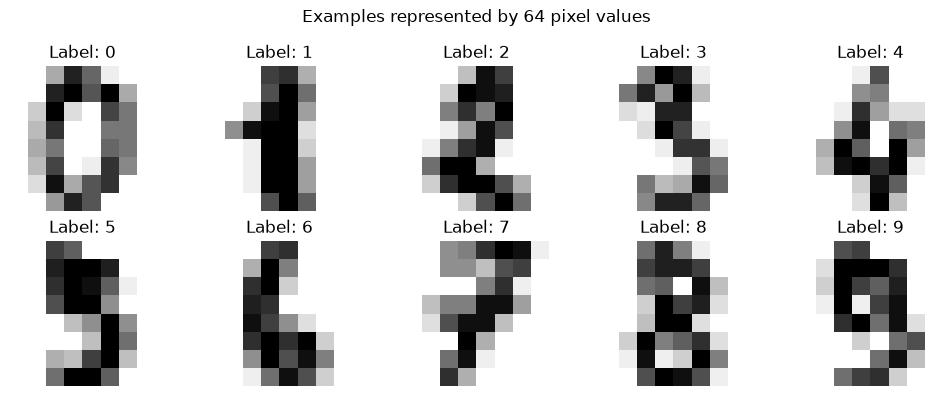

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), X[:10], y[:10]):
    ax.imshow(image.reshape(8, 8), cmap='gray_r')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Examples represented by 64 pixel values')
plt.tight_layout()
plt.show()

### Check your understanding

Before continuing, consider:

1. What information is contained in the 64 raw features?
2. Which variations might make classification difficult—for example, writing style, position or thickness?
3. Could fewer than 64 values still preserve the identity of a digit?

## Step 3 — Create training and testing sets

The model learns from the training set. The testing set contains unseen examples and helps us evaluate generalisation.

Notice that the Autoencoder target is also `X_train`. It learns the mapping:

$$x \rightarrow \text{Encoder} \rightarrow z \rightarrow \text{Decoder} \rightarrow \hat{x}$$

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('Training examples:', X_train.shape[0])
print('Testing examples:', X_test.shape[0])

Training examples: 1347
Testing examples: 450


## Step 4 — Build and train the Autoencoder

The network has the following structure:

$$64 \rightarrow 32 \rightarrow \text{bottleneck} \rightarrow 32 \rightarrow 64$$

The bottleneck forces the model to compress the 64 pixel values. We will initially use **two latent features**, which also allows us to plot the learned representation directly.

The output is compared with the original input. A lower mean squared error indicates better reconstruction.

In [5]:
# STUDENT ADJUSTMENT 1
# Start with 2. Later try 4, 8 or 16.
LATENT_DIM = 2

autoencoder = MLPRegressor(
    hidden_layer_sizes=(32, LATENT_DIM, 32),
    activation='logistic',
    solver='adam',
    learning_rate_init=0.01,
    batch_size=64,
    max_iter=250,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

# The input is also the target: X_train -> X_train
autoencoder.fit(X_train, X_train)

print('Training completed.')
print('Training epochs:', autoencoder.n_iter_)
print('Final training loss:', round(autoencoder.loss_, 5))

Training completed.
Training epochs: 244
Final training loss: 0.0203


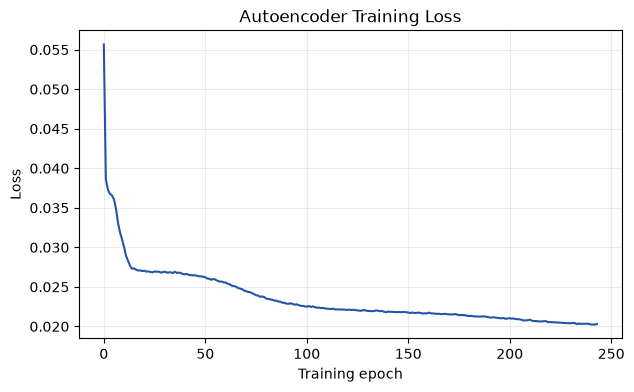

Observe whether the loss generally decreases and then stabilises.


In [6]:
plt.figure(figsize=(7, 4))
plt.plot(autoencoder.loss_curve_, color='#2455A4')
plt.xlabel('Training epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss')
plt.grid(alpha=0.25)
plt.show()

print('Observe whether the loss generally decreases and then stabilises.')

## Step 5 — Examine the reconstructed digits

The model has never seen the testing images during training. We now ask it to reconstruct them.

A reconstruction does not need to be pixel-perfect to preserve the main identity of a digit. However, too much information loss may make different digits look similar.

Test reconstruction MSE: 0.03944


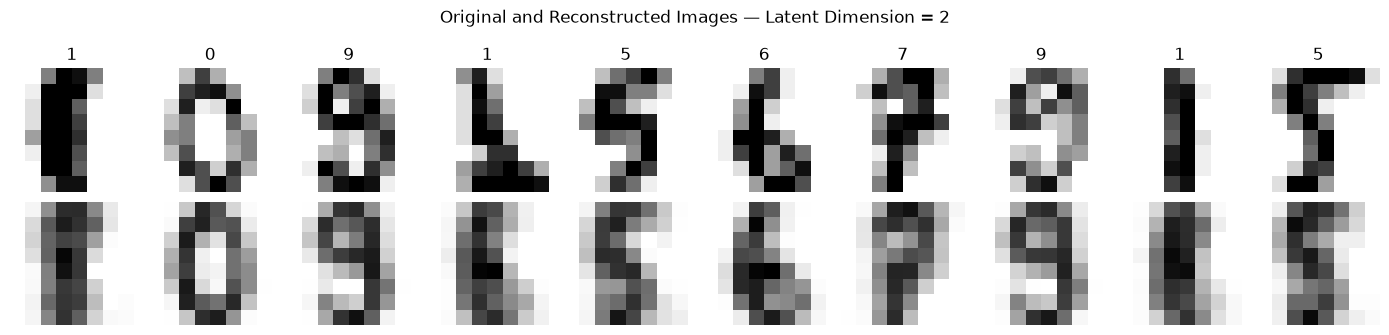

In [7]:
X_reconstructed = np.clip(autoencoder.predict(X_test), 0, 1)
reconstruction_mse = mean_squared_error(X_test, X_reconstructed)

print(f'Test reconstruction MSE: {reconstruction_mse:.5f}')

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
for i in range(10):
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    axes[0, i].set_title(str(y_test[i]))
    axes[0, i].axis('off')

    axes[1, i].imshow(X_reconstructed[i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Reconstructed', fontsize=11)
plt.suptitle(f'Original and Reconstructed Images — Latent Dimension = {LATENT_DIM}')
plt.tight_layout()
plt.show()

### Observe and record

- Which digits are reconstructed clearly?
- Which details have been lost?
- Do some reconstructed digits become difficult to distinguish?
- Is a lower reconstruction error sufficient to prove that the representation is useful?

## Step 6 — Extract the latent representation

The `MLPRegressor` does not provide a separate encoder method, so the next function passes the data through the first two hidden layers. The output of the bottleneck layer is the latent vector $z$.

For this model:

$$64\text{ raw features} \rightarrow 2\text{ learned latent features}$$

In [8]:
def logistic_activation(values):
    values = np.clip(values, -500, 500)
    return 1.0 / (1.0 + np.exp(-values))

def encode(model, data):
    first_hidden = logistic_activation(data @ model.coefs_[0] + model.intercepts_[0])
    latent = logistic_activation(first_hidden @ model.coefs_[1] + model.intercepts_[1])
    return latent

Z_train = encode(autoencoder, X_train)
Z_test = encode(autoencoder, X_test)

print('Original training shape:', X_train.shape)
print('Latent training shape:', Z_train.shape)
print('Compression ratio:', f'{X_train.shape[1]}:{Z_train.shape[1]}')
print('First latent representation:', np.round(Z_train[0], 3))

Original training shape: (1347, 64)
Latent training shape: (1347, 2)
Compression ratio: 64:2
First latent representation: [0.516 0.051]


## Step 7 — Visualise the learned latent space

Each point below represents one testing image. Its position is determined by the two learned latent features, while its colour shows the actual digit label.

The Autoencoder did not use these labels during training. Any grouping therefore emerged from the reconstruction objective.

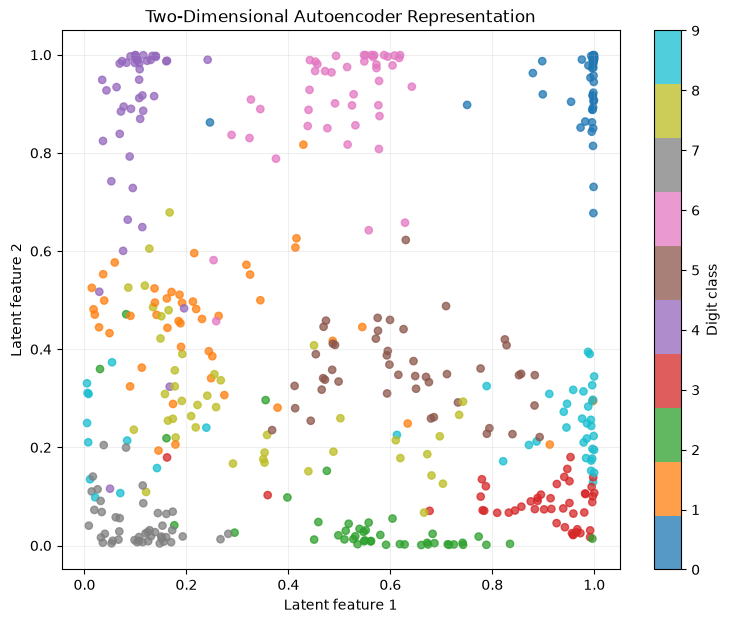

In [9]:
if LATENT_DIM == 2:
    plt.figure(figsize=(9, 7))
    scatter = plt.scatter(
        Z_test[:, 0], Z_test[:, 1],
        c=y_test, cmap='tab10', s=28, alpha=0.75
    )
    plt.xlabel('Latent feature 1')
    plt.ylabel('Latent feature 2')
    plt.title('Two-Dimensional Autoencoder Representation')
    plt.colorbar(scatter, ticks=range(10), label='Digit class')
    plt.grid(alpha=0.2)
    plt.show()
else:
    print('Direct plotting requires LATENT_DIM = 2.')
    print('For a larger latent space, reduce it to two dimensions before plotting.')

### Interpret the plot

Consider the following questions:

1. Do examples from the same digit form nearby groups?
2. Which digit groups overlap?
3. Does visible overlap necessarily mean the representation is poor?
4. Why might a representation trained for reconstruction not produce perfect class separation?

## Step 8 — Compare the Autoencoder with PCA

PCA is a linear dimensionality-reduction method. The Autoencoder can learn a nonlinear transformation because it uses activation functions.

We will compare both methods using the same two-dimensional output. This is a fairer comparison than using different representation sizes.

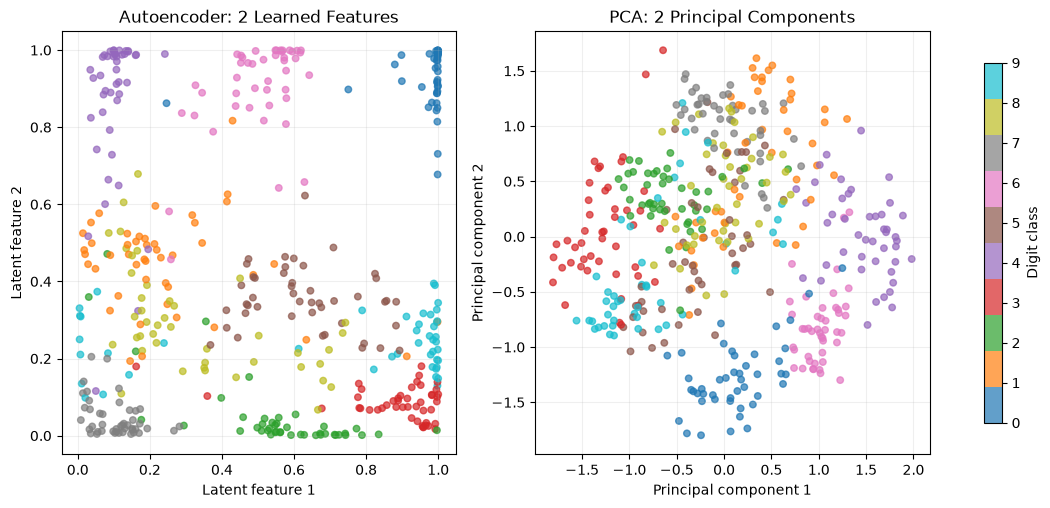

In [10]:
pca_2d = PCA(n_components=2, random_state=42)
P_train_2d = pca_2d.fit_transform(X_train)
P_test_2d = pca_2d.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

if LATENT_DIM == 2:
    axes[0].scatter(Z_test[:, 0], Z_test[:, 1], c=y_test, cmap='tab10', s=22, alpha=0.7)
    axes[0].set_title('Autoencoder: 2 Learned Features')
    axes[0].set_xlabel('Latent feature 1')
    axes[0].set_ylabel('Latent feature 2')
else:
    axes[0].text(0.5, 0.5, 'Set LATENT_DIM = 2\nfor a direct comparison',
                 ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Autoencoder')

pca_scatter = axes[1].scatter(
    P_test_2d[:, 0], P_test_2d[:, 1], c=y_test, cmap='tab10', s=22, alpha=0.7
)
axes[1].set_title('PCA: 2 Principal Components')
axes[1].set_xlabel('Principal component 1')
axes[1].set_ylabel('Principal component 2')

for ax in axes:
    ax.grid(alpha=0.2)

fig.colorbar(pca_scatter, ax=axes, ticks=range(10), label='Digit class', shrink=0.85)
plt.show()

### Compare the representations

- Which plot shows clearer class groupings?
- Which digit classes remain mixed?
- Does the nonlinear Autoencoder automatically outperform PCA?
- What other evidence would you require before deciding that one representation is better?

## Step 9 — Test the representations on a downstream task

A representation should be evaluated in relation to its intended purpose. Here, the downstream task is digit classification.

We will train the same simple Logistic Regression classifier using:

1. all 64 raw pixel features;
2. two PCA features; and
3. two learned Autoencoder features.

This comparison asks whether the compressed representations retain enough class-related information.

In [11]:
def classification_accuracy(train_features, test_features, train_labels, test_labels):
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_features)
    test_scaled = scaler.transform(test_features)

    classifier = LogisticRegression(max_iter=2000, random_state=42)
    classifier.fit(train_scaled, train_labels)
    predictions = classifier.predict(test_scaled)
    return accuracy_score(test_labels, predictions)

raw_accuracy = classification_accuracy(X_train, X_test, y_train, y_test)
pca_accuracy = classification_accuracy(P_train_2d, P_test_2d, y_train, y_test)
ae_accuracy = classification_accuracy(Z_train, Z_test, y_train, y_test)

print(f'Raw pixels ({X_train.shape[1]} features):       {raw_accuracy:.3f}')
print(f'PCA representation (2 features):       {pca_accuracy:.3f}')
print(f'Autoencoder representation ({LATENT_DIM} features): {ae_accuracy:.3f}')

Raw pixels (64 features):       0.978
PCA representation (2 features):       0.591
Autoencoder representation (2 features): 0.791


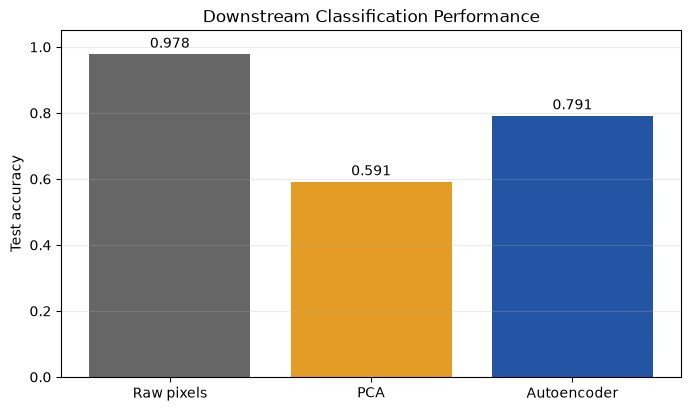

In [12]:
names = ['Raw pixels', 'PCA', 'Autoencoder']
scores = [raw_accuracy, pca_accuracy, ae_accuracy]
colours = ['#666666', '#E39C26', '#2455A4']

plt.figure(figsize=(8, 4.5))
bars = plt.bar(names, scores, color=colours)
plt.ylim(0, 1.05)
plt.ylabel('Test accuracy')
plt.title('Downstream Classification Performance')
plt.grid(axis='y', alpha=0.25)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}', ha='center')
plt.show()

### What do the results mean?

The raw data retains the most information, while the two-dimensional representations provide strong compression. A representation can therefore be valuable even if it does not produce the highest classification accuracy.

Discuss:

- Is comparing 64 raw features with only two latent features completely fair?
- Which representation provides the best balance between compactness and accuracy?
- Why might the reconstruction-trained Autoencoder discard information useful for classification?
- Would a supervised representation be expected to create clearer class separation?

## Step 10 — Student experiment: change the bottleneck size

Now investigate how the size of the latent representation affects the result.

Change `LATENT_DIM` in **Step 4**, then rerun Steps 4–6 and Step 9. Suggested values are:

- `LATENT_DIM = 2` — very strong compression and direct visualisation;
- `LATENT_DIM = 4` — more capacity;
- `LATENT_DIM = 8` — moderate compression; and
- `LATENT_DIM = 16` — less compression and more retained information.

Record your results in the table below.

| Latent dimension | Reconstruction MSE | Classification accuracy | Main observation |
|---:|---:|---:|---|
| 2 |  |  |  |
| 4 |  |  |  |
| 8 |  |  |  |
| 16 |  |  |  |

### Expected pattern

A larger bottleneck will usually improve reconstruction because the model can retain more information. Classification may also improve, but the relationship is not guaranteed to be perfectly linear. Training randomness and the reconstruction objective can affect the result.

## Optional challenge — Compare PCA and the Autoencoder fairly

After choosing a new `LATENT_DIM`, create a PCA representation with exactly the same number of components:

```python
pca_equal = PCA(n_components=LATENT_DIM, random_state=42)
P_train_equal = pca_equal.fit_transform(X_train)
P_test_equal = pca_equal.transform(X_test)

pca_equal_accuracy = classification_accuracy(
    P_train_equal, P_test_equal, y_train, y_test
)

print('PCA accuracy:', pca_equal_accuracy)
print('Autoencoder accuracy:', ae_accuracy)
```

Then answer: Does the nonlinear Autoencoder outperform PCA at every representation size?

## Critical thinking — Good reconstruction or useful representation?

Respond briefly to each question:

1. Can an Autoencoder reconstruct an input well but still learn a poor representation for classification? Why?
2. What information should a useful digit representation preserve?
3. What variations should it ideally ignore?
4. How could the training objective be changed to encourage class separation?
5. Could a latent representation still encode sensitive information even if the raw input is removed?

## Assessment 3 connection

Apply the same thinking to your final deep learning project:

- What is the raw representation of your input data?
- Which information should your model preserve?
- Which noise or irrelevant variation should it ignore?
- Could a learned representation improve the task?
- How would you evaluate whether the representation is useful?
- What interpretability, bias, privacy or fairness concerns may arise?

> A strong project discussion should explain not only which model was used, but also what information its representation is expected to capture.

## Activity summary

In this notebook, you:

- started with images represented by 64 raw pixel values;
- trained an Autoencoder without using class labels;
- compressed each image into a latent representation;
- visualised the learned representation;
- compared Autoencoder and PCA representations;
- evaluated the representations through a downstream classification task; and
- investigated the effect of changing the bottleneck size.

**Final takeaway:** A compact representation is not automatically a useful one. Its quality must be evaluated in relation to the task, data and intended use.